In [10]:
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from src.sgtlib.utils.sgt_utils import gen_spider_plot, gen_scaling_plot

## Uncomment to install Libraries (if not installed)
#!pip3 install openpyxl

In [35]:
# Read the Excel file
all_sheets = pd.read_excel('analysis/n_10/AllData.xlsx', sheet_name=None)
pdf_file = "analysis/n_10/scaling_results-10.pdf"

plt_figs = []

In [36]:
# Filter the relevant materials and parameters
materials = ['BSE 017', 'BSE 011', 'BSE 024', 'BSE 025']
material_names = ['PAN/CGO', 'Carb. PAN', 'PAN', 'Carb. PAN/CGO']
parameters = ['Nodes', 'Edges', 'AD', 'Diameter', 'GD', 'BC', 'CC', 'EC']

material_labels = {key: name for (name, key) in zip(material_names, materials)}

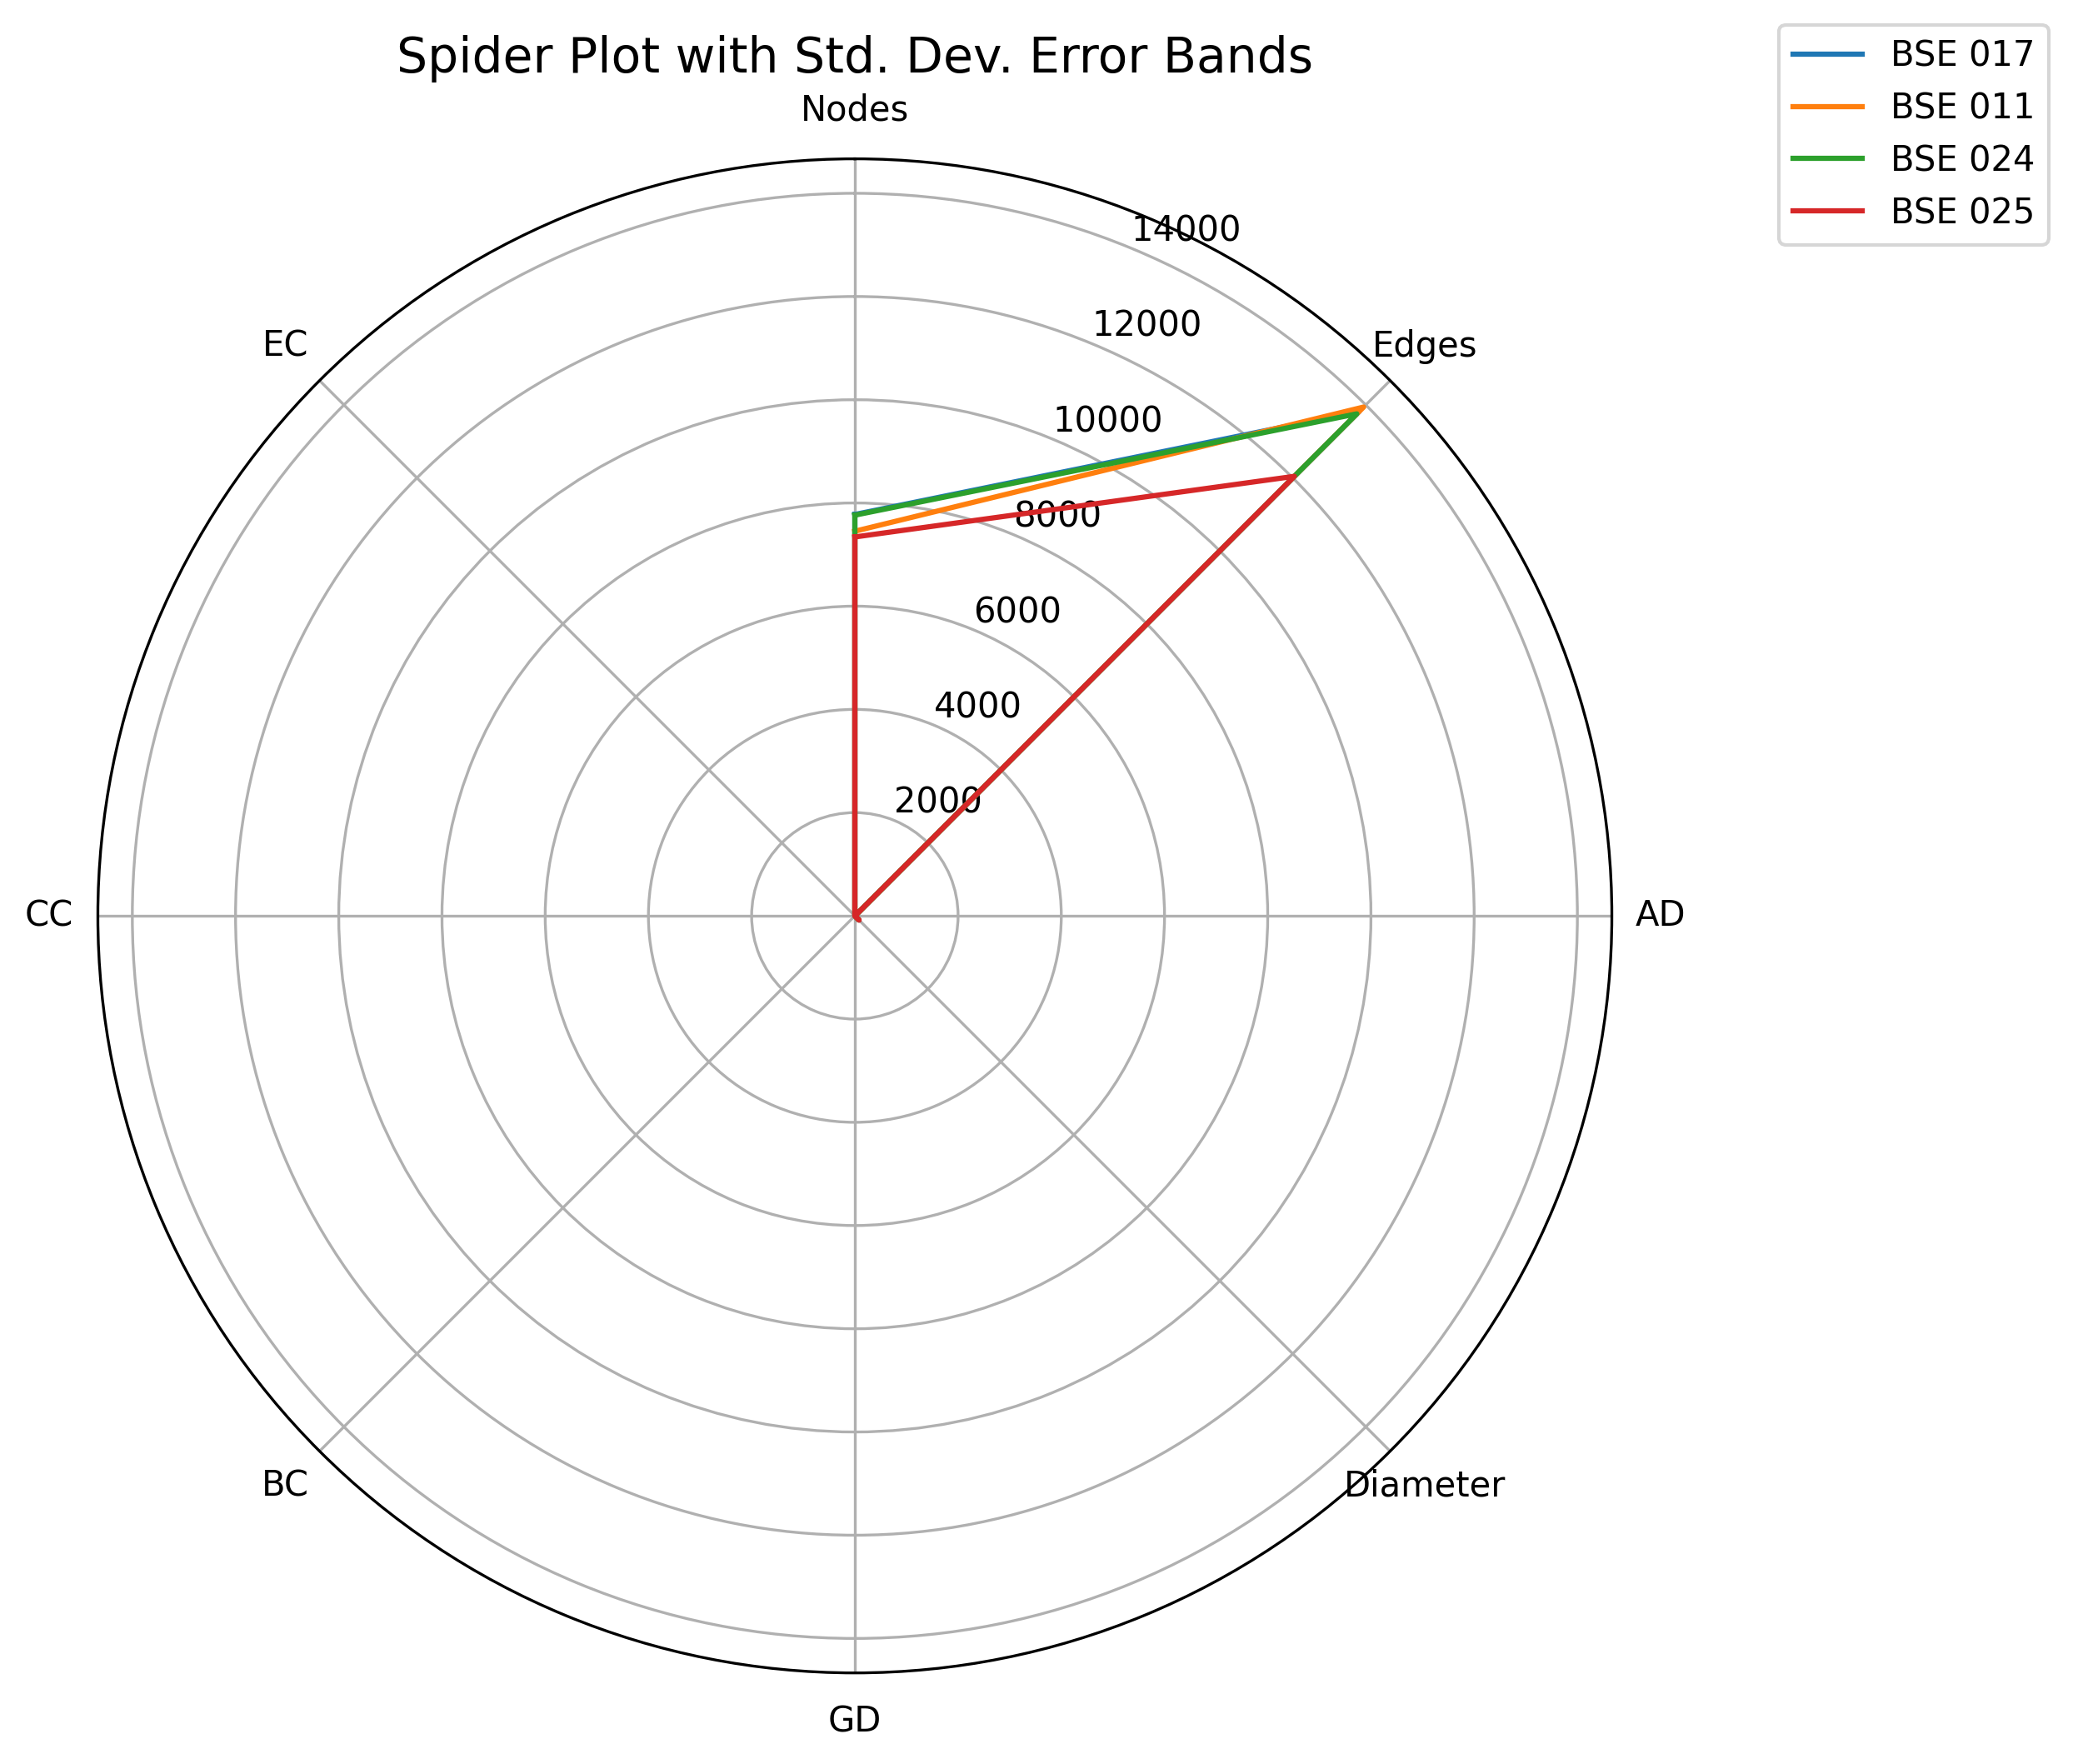

In [37]:
"""
Spider Plot
"""
df_sgt = all_sheets['SGT Descriptors']
plt_fig = gen_spider_plot(df_sgt, materials, parameters)
plt_figs.append(plt_fig)

In [ ]:

def power_law_function(x, a, k):
    """
        A best-fit model that follows the power law distribution: y = a * x^(-k),
        where a and k are fitting parameters.

        Args:
            x (np.array): Array of x values
            a (float): intercept or scale factor/constant (shifts curve up/down). It does not affect the shape/decay rate of the curve (only how high the curve starts)
            k (float): exponent of the power law distribution. It defines how fast y decays as x increases.
    """
    return a * x ** (-k)

"""
# we define x 100 values from a range of 0-1000
x_vals = np.linspace(0, 1000, 100)

for sheet_name, df_scl in all_sheets.items():
    df_scl.columns = df_scl.iloc[0]
    df_scl = df_scl[1:]
    df_scl = df_scl.dropna(axis=1)
"""

C:\Users\owuor\owProjects\StructuralGT\.venv_sgt\Lib\site-packages\scipy\stats\_resampling.py:960: RuntimeWarning: invalid value encountered in scalar subtract
  cmps = null_distribution >= observed - gamma
C:\Users\owuor\owProjects\StructuralGT\.venv_sgt\Lib\site-packages\scipy\stats\_continuous_distns.py:6930: RuntimeWarning: divide by zero encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
C:\Users\owuor\owProjects\StructuralGT\.venv_sgt\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\owuor\owProjects\StructuralGT\.venv_sgt\Lib\site-packages\scipy\stats\_continuous_distns.py:6930: RuntimeWarning: invalid value encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)


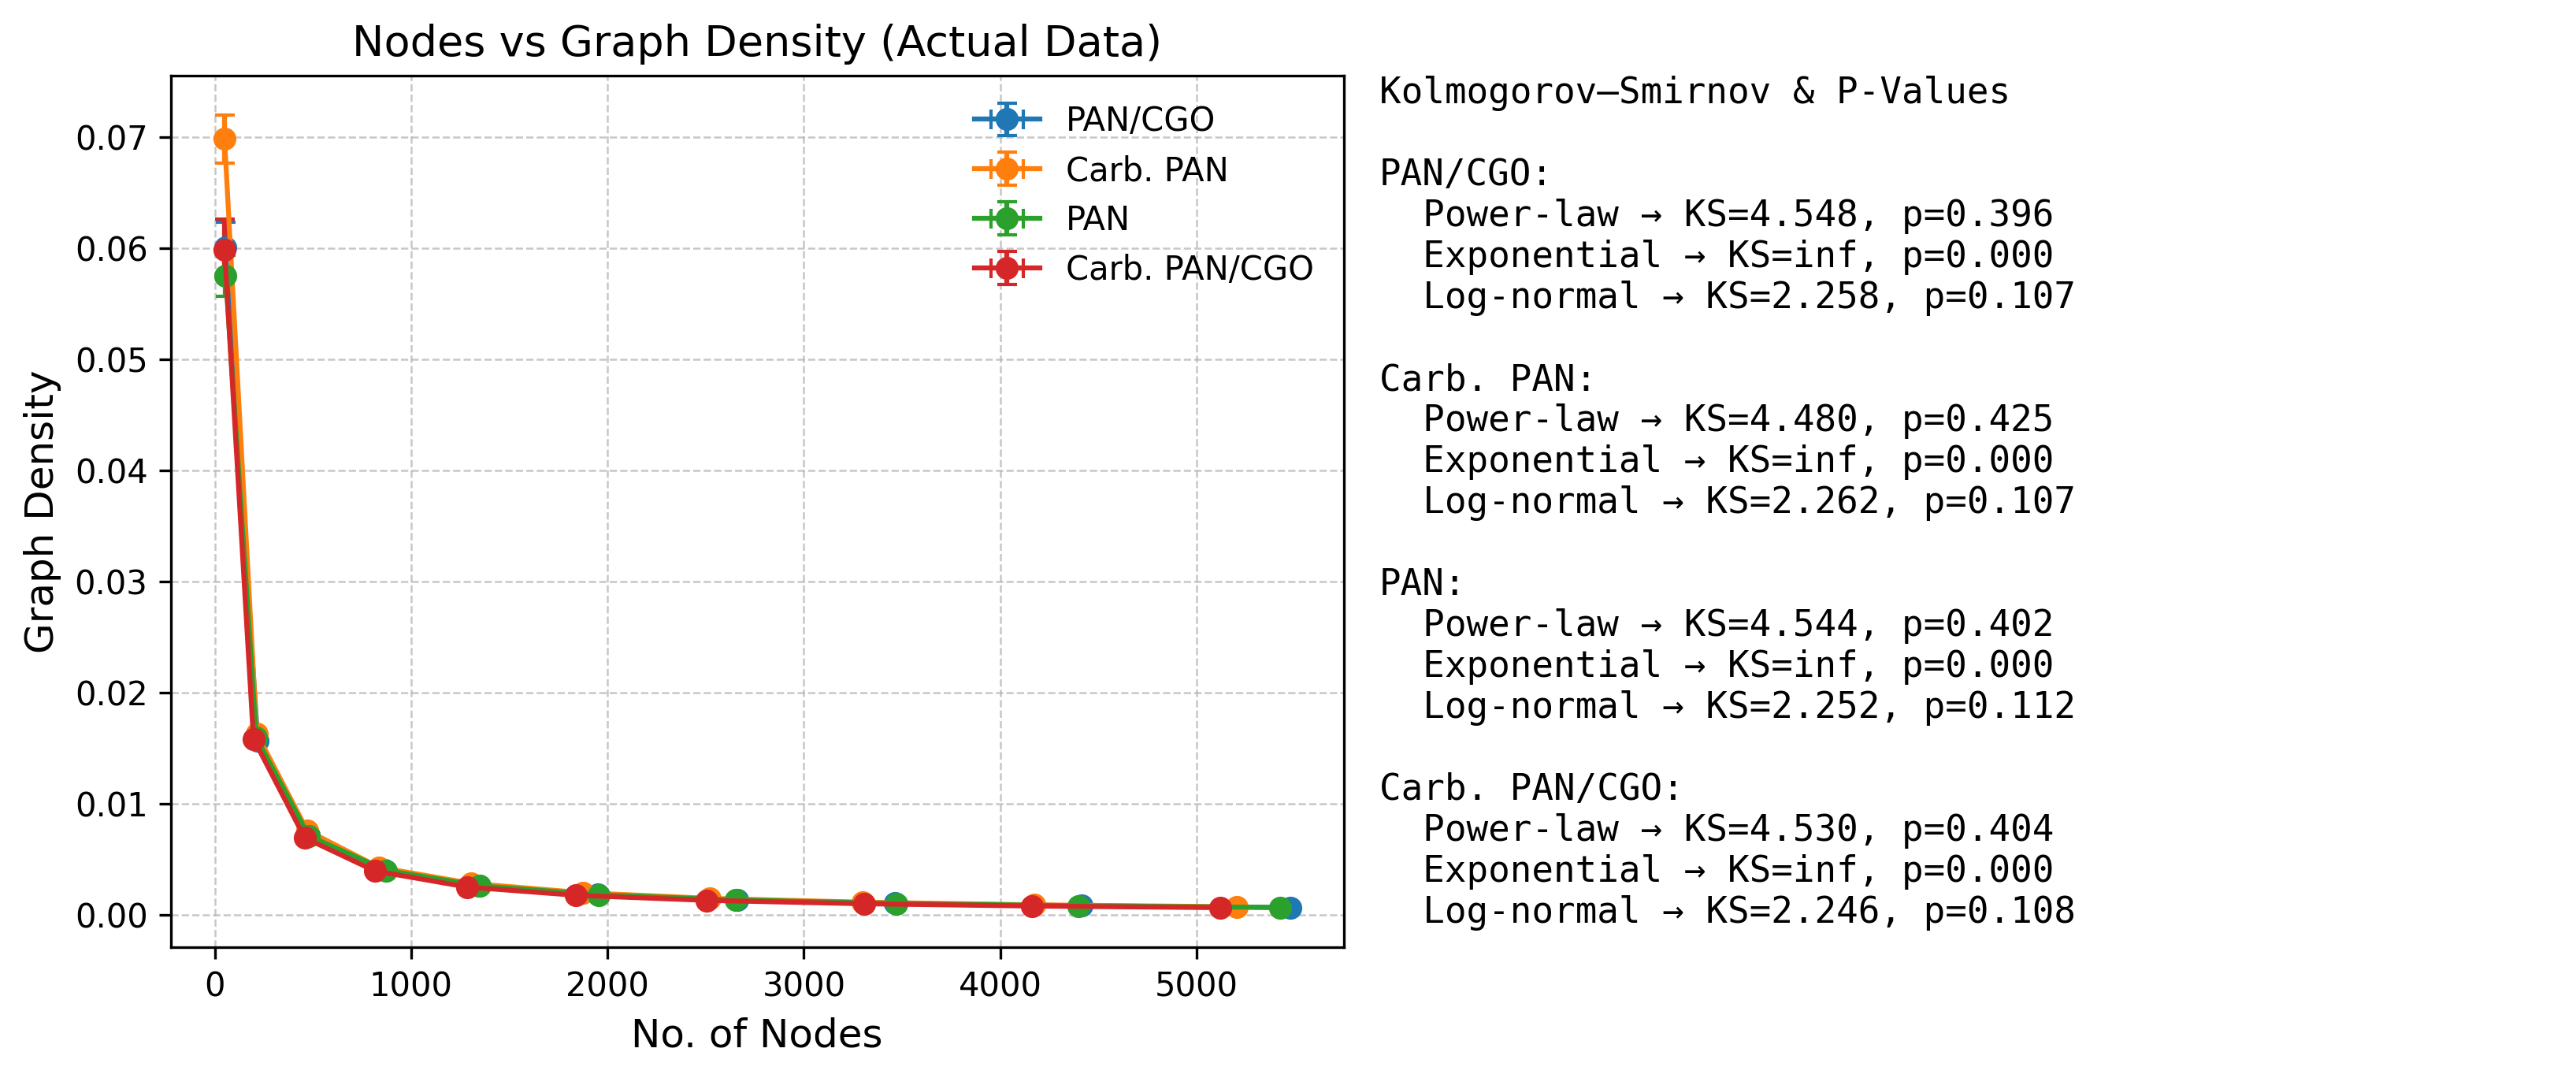

In [38]:
"""
Graph Density
"""
df_dens = all_sheets['Nodes-G. Density']
plt_fig = gen_scaling_plot("Graph Density", df_dens, material_labels)
plt_figs.append(plt_fig)

In [ ]:
"""
Betweenness
"""
df_bet = all_sheets['Nodes-Avg. Btwn. C']
plt_fig = gen_scaling_plot("Betweenness Centrality", df_bet, material_labels)
plt_figs.append(plt_fig)

In [ ]:
"""
Closeness
"""
df_clo = all_sheets['Nodes-Avg. Close. C']
plt_fig = gen_scaling_plot("Closeness Centrality", df_clo, material_labels)
plt_figs.append(plt_fig)

In [ ]:
"""
Eigenvector
"""
df_eig = all_sheets['Nodes-Avg. EigVec. C.']
plt_fig = gen_scaling_plot("Eigenvector Centrality", df_eig, material_labels)
plt_figs.append(plt_fig)

In [ ]:
"""
No. Edges
"""
df_edges = all_sheets['Nodes-Edges']
plt_fig = gen_scaling_plot("Edges", df_edges, material_labels)
plt_figs.append(plt_fig)

In [ ]:
"""
Average Degree
"""
df_deg = all_sheets['Nodes-Degree']
plt_fig = gen_scaling_plot("Average Degree", df_deg, material_labels)
plt_figs.append(plt_fig)

In [ ]:
"""
Network Diameter
"""
df_dia = all_sheets['Nodes-Diameter']
plt_fig = gen_scaling_plot("Network Diameter", df_dia, material_labels)
plt_figs.append(plt_fig)

In [66]:
with PdfPages(pdf_file) as pdf:
    for fig in plt_figs:
        pdf.savefig(fig)